# Анализ бенчмарков оптимизаторов транзакций

Сравнение алгоритмов **Greedy**, **Dinic** и **Edmonds–Karp** для обоснования выбора алгоритма в сервисе оптимизации транзакций (дипломная работа).

Данные: `dataset_greedy.csv`, `dataset_dinic.csv`, `dataset_karp.csv` (генерируются из Go-бенчмарков через `run.sh` и `bench_to_df.py`).

In [119]:
# Установка зависимостей (выполнить один раз при первом запуске)
%pip install pandas matplotlib numpy --quiet

Note: you may need to restart the kernel to use updated packages.


In [120]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Путь к CSV: текущая папка (analitic) или типичные варианты при разных cwd
DATA_DIR = os.getcwd()
cwd = os.getcwd()
for d in [cwd, os.path.join(cwd, "analitic"), os.path.join(cwd, "ff-common", "optimizers", "tests", "analitic")]:
    if os.path.exists(os.path.join(d, "dataset_dinic.csv")):
        DATA_DIR = d
        break
print("DATA_DIR:", DATA_DIR)

def load_datasets():
    dfs = {}
    for name, f in [("Greedy", "dataset_greedy.csv"), ("Dinic", "dataset_dinic.csv"), ("EdmondsKarp", "dataset_karp.csv")]:
        path = os.path.join(DATA_DIR, f)
        if os.path.exists(path):
            dfs[name] = pd.read_csv(path)
        else:
            print(f"Файл не найден: {path}")
    return dfs

datasets = load_datasets()
if datasets:
    df_all = pd.concat(datasets.values(), ignore_index=True)
    print("Загружено строк по алгоритмам:")
    print(df_all.groupby("algorithm").size())
    print(df_all.head())

DATA_DIR: /Users/ivasnev/Some Projects/FinFlow/ff-common/optimizers/tests/analitic
Загружено строк по алгоритмам:
algorithm
Dinic          120
EdmondsKarp    120
Greedy         119
dtype: int64
  algorithm  nodes  transactions  ns_per_op  collapse_pct  \
0    Greedy      5            10    18363.0         34.83   
1    Greedy      5            20    20349.0         56.09   
2    Greedy      5            30    21967.0         68.09   
3    Greedy      5            40    25161.0         75.39   
4    Greedy      5            50    23922.0         80.11   

   input_after_collapse  collapse_ns_per_op  optimize_ns_per_op  \
0                 6.517              1397.0              6271.0   
1                 8.781              2033.0              7634.0   
2                 9.572              2679.0              8256.0   
3                 9.845              3718.0              9438.0   
4                 9.943              3866.0              8597.0   

   reduce_success_pct  reduction_len

## Блок 1: Время выполнения и число транзакций

Графики зависимости времени (мкс/оп) от числа транзакций для фиксированных чисел узлов: 5, 20, 50, 110, 200. На каждом графике — три алгоритма для сравнения.

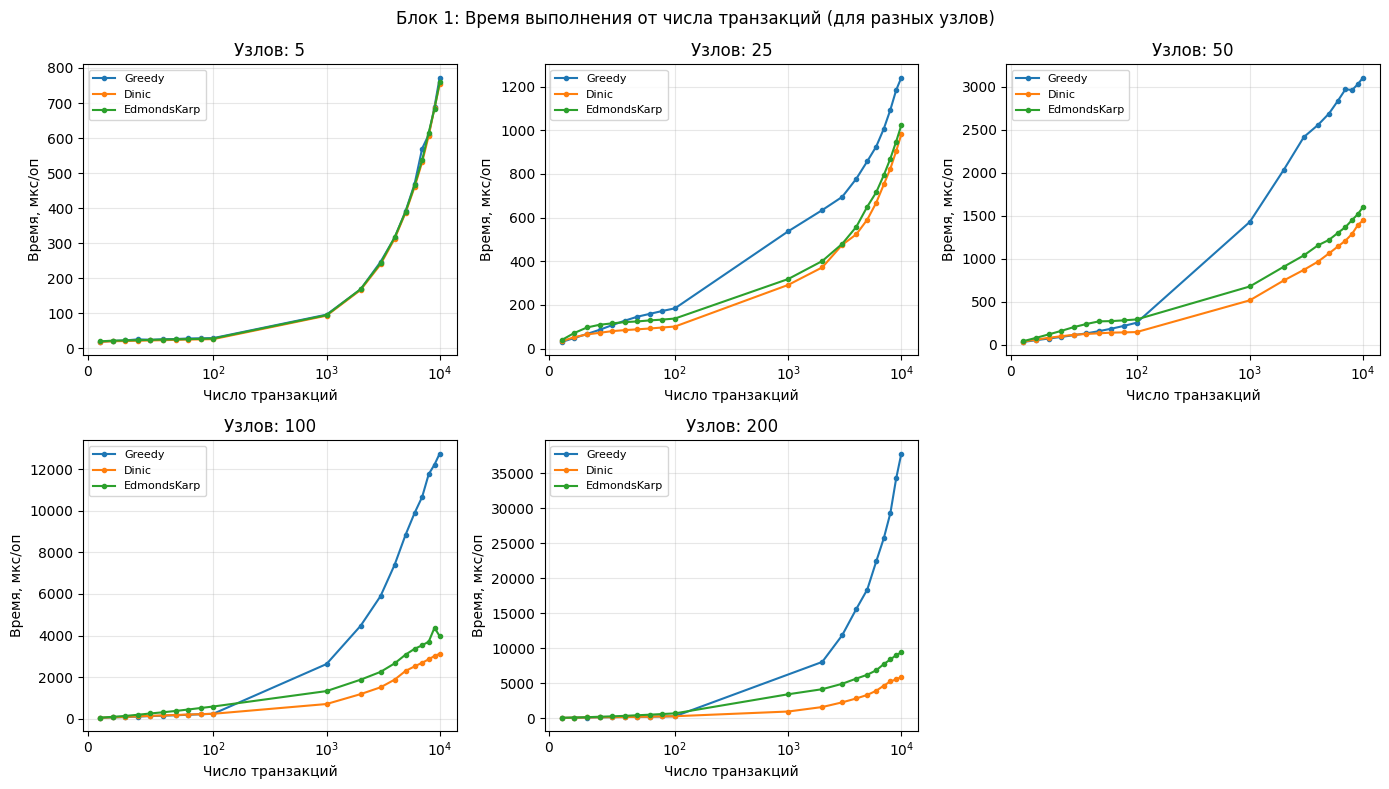

In [121]:
NODES_FOR_PLOTS = [5, 25, 50, 100, 200]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, n in enumerate(NODES_FOR_PLOTS):
    sub = df_all[df_all["nodes"] == n].copy()
    if sub.empty:
        axes[i].set_visible(False)
        continue
    for algo in ["Greedy", "Dinic", "EdmondsKarp"]:
        d = sub[sub["algorithm"] == algo].sort_values("transactions")
        if d.empty:
            continue
        axes[i].plot(d["transactions"], d["ns_per_op"] / 1000, "o-", label=algo, markersize=3)
    axes[i].set_xlabel("Число транзакций")
    axes[i].set_ylabel("Время, мкс/оп")
    axes[i].set_title(f"Узлов: {n}")
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xscale("symlog", linthresh=100)
axes[5].set_visible(False)
plt.suptitle("Блок 1: Время выполнения от числа транзакций (для разных узлов)")
plt.tight_layout()
plt.show()

## Блок 2: Аллокации и число транзакций

Графики зависимости числа аллокаций на операцию от числа транзакций для тех же узлов (5, 20, 50, 110, 200). Меньше аллокаций — меньше нагрузка на сборщик мусора.

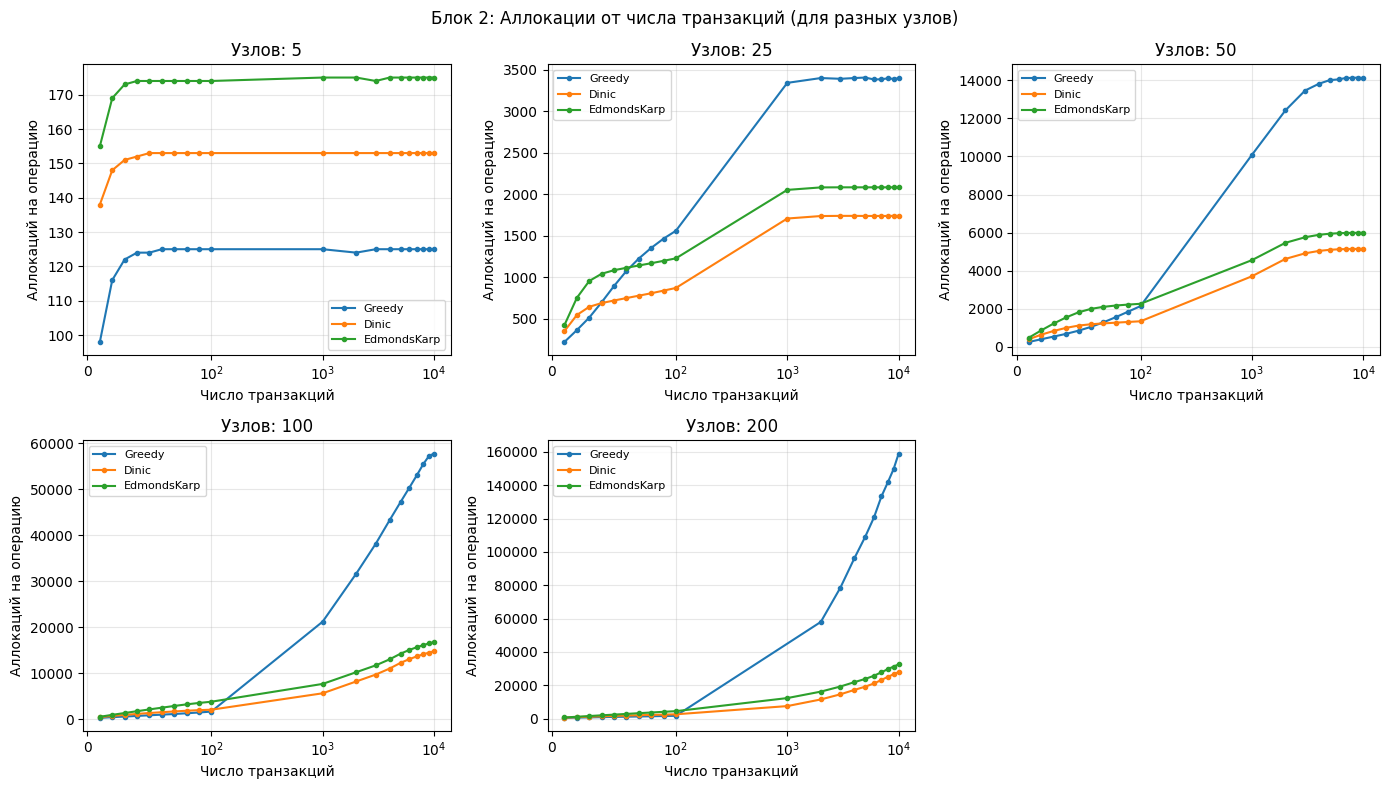

In [122]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, n in enumerate(NODES_FOR_PLOTS):
    sub = df_all[df_all["nodes"] == n].copy()
    if sub.empty:
        axes[i].set_visible(False)
        continue
    for algo in ["Greedy", "Dinic", "EdmondsKarp"]:
        d = sub[sub["algorithm"] == algo].sort_values("transactions")
        if d.empty:
            continue
        axes[i].plot(d["transactions"], d["allocs_per_op"], "o-", label=algo, markersize=3)
    axes[i].set_xlabel("Число транзакций")
    axes[i].set_ylabel("Аллокаций на операцию")
    axes[i].set_title(f"Узлов: {n}")
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xscale("symlog", linthresh=100)
axes[5].set_visible(False)
plt.suptitle("Блок 2: Аллокации от числа транзакций (для разных узлов)")
plt.tight_layout()
plt.show()

## Блок 3: Тепловые карты

Все тепловые карты в одном месте для удобного сравнения.

1. **Время (нс/оп)** — по каждому алгоритму на общей шкале + отношение Karp/Dinic (красный = Karp медленнее).
2. **Качество (reduction_len_pct)** — средний % сокращения числа переводов; выше — лучше; у Greedy может быть отрицательным.
3. **Память: аллокации (allocs/op)** и **байты (KB/op)** — общая шкала по всем алгоритмам.

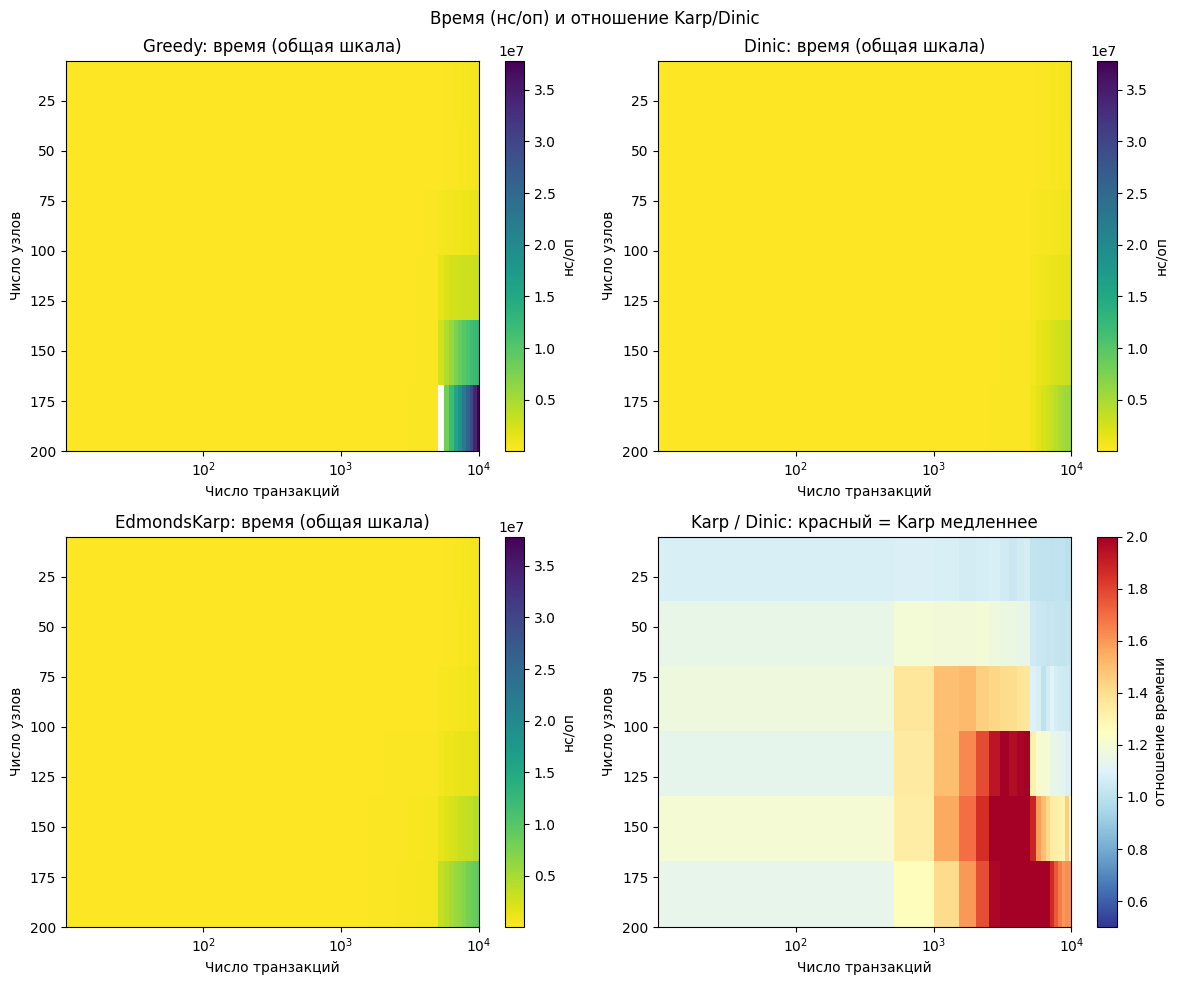

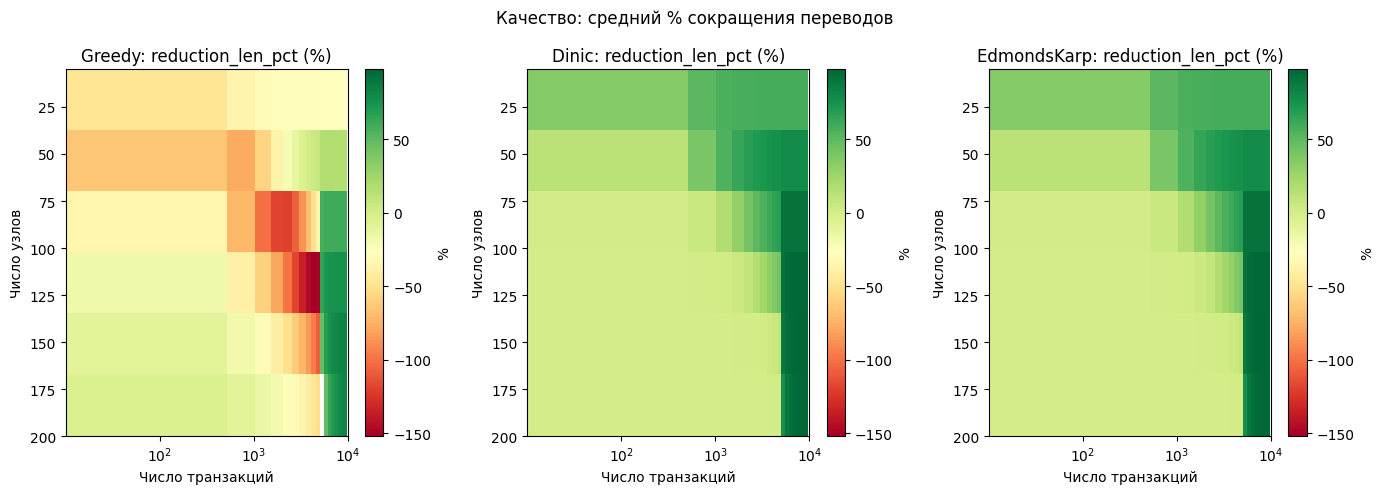

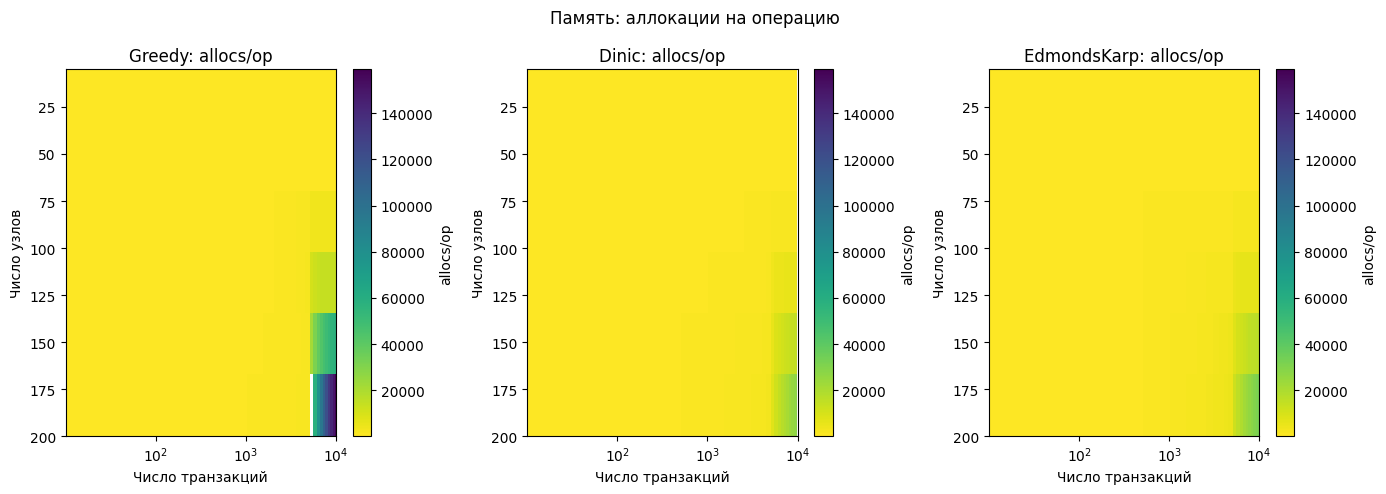

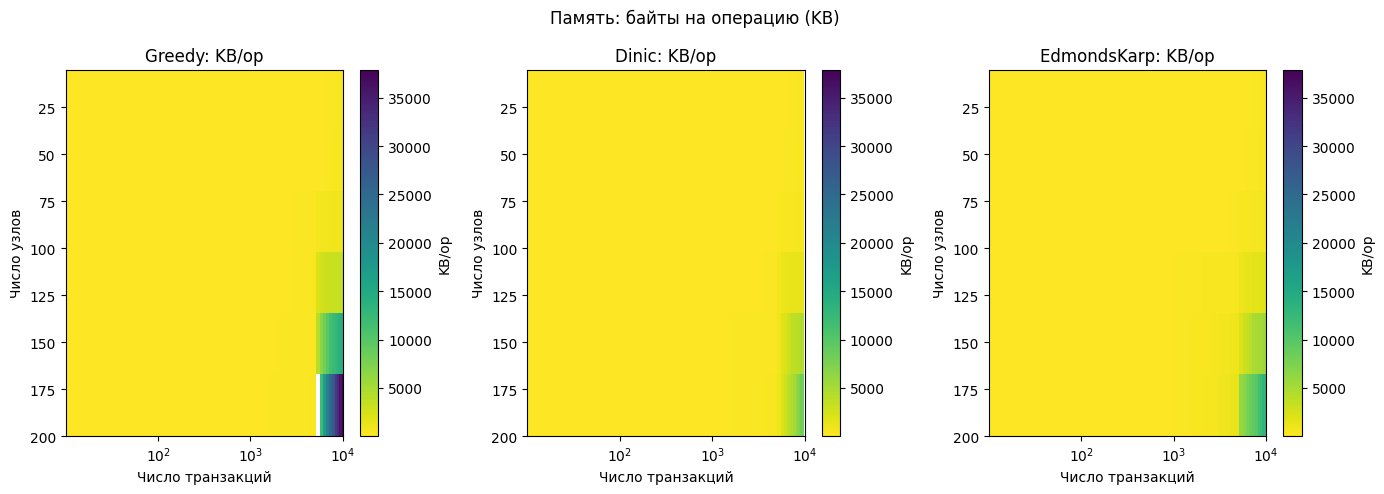

In [123]:
def pivot_metric(df, metric="ns_per_op"):
    return df.pivot_table(index="nodes", columns="transactions", values=metric, aggfunc="mean")

# Общая шкала времени по всем алгоритмам (линейная) — чтобы сравнение по цвету было честным
all_times = []
for algo in ["Greedy", "Dinic", "EdmondsKarp"]:
    sub = df_all[df_all["algorithm"] == algo]
    mat = pivot_metric(sub).sort_index(axis=0).sort_index(axis=1)
    if not mat.empty:
        all_times.append(mat.values)
vmin = np.nanmin(np.concatenate(all_times))
vmax = np.nanmax(np.concatenate(all_times))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ax_list = axes.flatten()
for idx, algo in enumerate(["Greedy", "Dinic", "EdmondsKarp"]):
    sub = df_all[df_all["algorithm"] == algo]
    mat = pivot_metric(sub).sort_index(axis=0).sort_index(axis=1)
    if mat.empty:
        continue
    nodes = mat.index.values
    trans = mat.columns.values
    Z = mat.values
    im = ax_list[idx].imshow(Z, aspect="auto", cmap="viridis_r", vmin=vmin, vmax=vmax,
                             extent=[trans.min(), trans.max(), nodes.max(), nodes.min()])
    ax_list[idx].set_xscale("symlog", linthresh=100)
    ax_list[idx].set_xlabel("Число транзакций")
    ax_list[idx].set_ylabel("Число узлов")
    ax_list[idx].set_title(f"{algo}: время (общая шкала)")
    plt.colorbar(im, ax=ax_list[idx], label="нс/оп")

# Справа внизу: Karp / Dinic — где >1, там Karp медленнее (Диниц лучше)
p_dinic = pivot_metric(df_all[df_all["algorithm"] == "Dinic"]).sort_index(axis=0).sort_index(axis=1)
p_karp  = pivot_metric(df_all[df_all["algorithm"] == "EdmondsKarp"]).sort_index(axis=0).sort_index(axis=1)
# Выравниваем индексы
common_idx = p_dinic.index.intersection(p_karp.index)
common_col = p_dinic.columns.intersection(p_karp.columns)
p_d = p_dinic.reindex(index=common_idx, columns=common_col)
p_k = p_karp.reindex(index=common_idx, columns=common_col)
ratio = p_k.values / (p_d.values + 1e-9)
nodes = p_d.index.values
trans = p_d.columns.values
im = ax_list[3].imshow(ratio, aspect="auto", cmap="RdYlBu_r", vmin=0.5, vmax=2,
                       extent=[trans.min(), trans.max(), nodes.max(), nodes.min()])
ax_list[3].axhline(y=nodes.max(), xmin=0, xmax=1, color="none")
ax_list[3].set_xscale("symlog", linthresh=100)
ax_list[3].set_xlabel("Число транзакций")
ax_list[3].set_ylabel("Число узлов")
ax_list[3].set_title("Karp / Dinic: красный = Karp медленнее")
plt.colorbar(im, ax=ax_list[3], label="отношение времени")
plt.suptitle("Время (нс/оп) и отношение Karp/Dinic")
plt.tight_layout()
plt.show()

# 2) Качество: reduction_len_pct
all_red = []
for algo in ["Greedy", "Dinic", "EdmondsKarp"]:
    sub = df_all[df_all["algorithm"] == algo]
    mat = pivot_metric(sub, metric="reduction_len_pct").sort_index(axis=0).sort_index(axis=1)
    if not mat.empty:
        all_red.append(mat.values)
rmin = np.nanmin(np.concatenate(all_red)) if all_red else 0
rmax = np.nanmax(np.concatenate(all_red)) if all_red else 100
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for idx, algo in enumerate(["Greedy", "Dinic", "EdmondsKarp"]):
    sub = df_all[df_all["algorithm"] == algo]
    mat = pivot_metric(sub, metric="reduction_len_pct").sort_index(axis=0).sort_index(axis=1)
    if mat.empty:
        continue
    nodes, trans = mat.index.values, mat.columns.values
    im = axes[idx].imshow(mat.values, aspect="auto", cmap="RdYlGn", vmin=rmin, vmax=rmax,
                          extent=[trans.min(), trans.max(), nodes.max(), nodes.min()])
    axes[idx].set_xscale("symlog", linthresh=100)
    axes[idx].set_xlabel("Число транзакций")
    axes[idx].set_ylabel("Число узлов")
    axes[idx].set_title(f"{algo}: reduction_len_pct (%)")
    plt.colorbar(im, ax=axes[idx], label="%")
plt.suptitle("Качество: средний % сокращения переводов")
plt.tight_layout()
plt.show()

# 3) Память: allocs_per_op
all_allocs = []
for algo in ["Greedy", "Dinic", "EdmondsKarp"]:
    sub = df_all[df_all["algorithm"] == algo]
    mat = pivot_metric(sub, metric="allocs_per_op").sort_index(axis=0).sort_index(axis=1)
    if not mat.empty:
        all_allocs.append(mat.values)
amin = np.nanmin(np.concatenate(all_allocs)) if all_allocs else 0
amax = np.nanmax(np.concatenate(all_allocs)) if all_allocs else 1
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for idx, algo in enumerate(["Greedy", "Dinic", "EdmondsKarp"]):
    sub = df_all[df_all["algorithm"] == algo]
    mat = pivot_metric(sub, metric="allocs_per_op").sort_index(axis=0).sort_index(axis=1)
    if mat.empty:
        continue
    nodes, trans = mat.index.values, mat.columns.values
    im = axes[idx].imshow(mat.values, aspect="auto", cmap="viridis_r", vmin=amin, vmax=amax,
                          extent=[trans.min(), trans.max(), nodes.max(), nodes.min()])
    axes[idx].set_xscale("symlog", linthresh=100)
    axes[idx].set_xlabel("Число транзакций")
    axes[idx].set_ylabel("Число узлов")
    axes[idx].set_title(f"{algo}: allocs/op")
    plt.colorbar(im, ax=axes[idx], label="allocs/op")
plt.suptitle("Память: аллокации на операцию")
plt.tight_layout()
plt.show()

# 4) Память: bytes (KB)
df_all["bytes_kb"] = df_all["bytes_per_op"] / 1024
all_bytes = []
for algo in ["Greedy", "Dinic", "EdmondsKarp"]:
    sub = df_all[df_all["algorithm"] == algo]
    mat = pivot_metric(sub, metric="bytes_kb").sort_index(axis=0).sort_index(axis=1)
    if not mat.empty:
        all_bytes.append(mat.values)
bmin = np.nanmin(np.concatenate(all_bytes)) if all_bytes else 0
bmax = np.nanmax(np.concatenate(all_bytes)) if all_bytes else 1
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for idx, algo in enumerate(["Greedy", "Dinic", "EdmondsKarp"]):
    sub = df_all[df_all["algorithm"] == algo]
    mat = pivot_metric(sub, metric="bytes_kb").sort_index(axis=0).sort_index(axis=1)
    if mat.empty:
        continue
    nodes, trans = mat.index.values, mat.columns.values
    im = axes[idx].imshow(mat.values, aspect="auto", cmap="viridis_r", vmin=bmin, vmax=bmax,
                          extent=[trans.min(), trans.max(), nodes.max(), nodes.min()])
    axes[idx].set_xscale("symlog", linthresh=100)
    axes[idx].set_xlabel("Число транзакций")
    axes[idx].set_ylabel("Число узлов")
    axes[idx].set_title(f"{algo}: KB/op")
    plt.colorbar(im, ax=axes[idx], label="KB/op")
plt.suptitle("Память: байты на операцию (KB)")
plt.tight_layout()
plt.show()

См. Блок 3 выше (качество, память).

In [124]:
# Визуализация перенесена в Блок 3 выше.

## Блок 4: Дополнительные метрики (тепловые карты)

Тепловые карты по метрикам: **collapse_pct** (доля схлопнутых транзакций), **input_after_collapse** (средний размер входа после схлопывания), **collapse_ns_per_op** и **optimize_ns_per_op** (время на схлопывание и на оптимизацию). Для каждой метрики — три карты (по алгоритмам) на общей шкале.

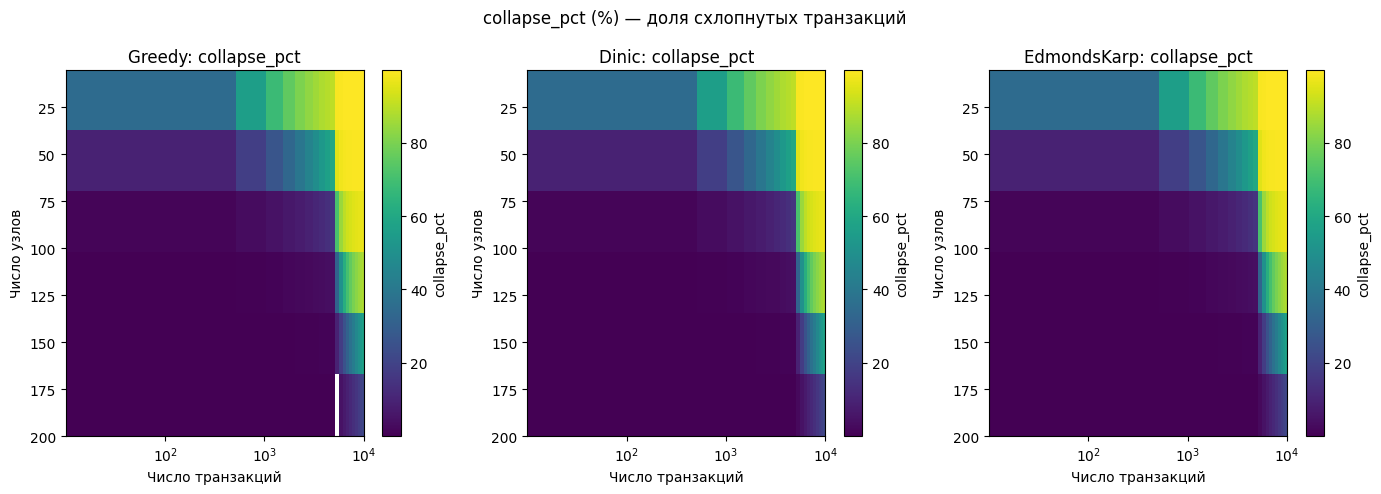

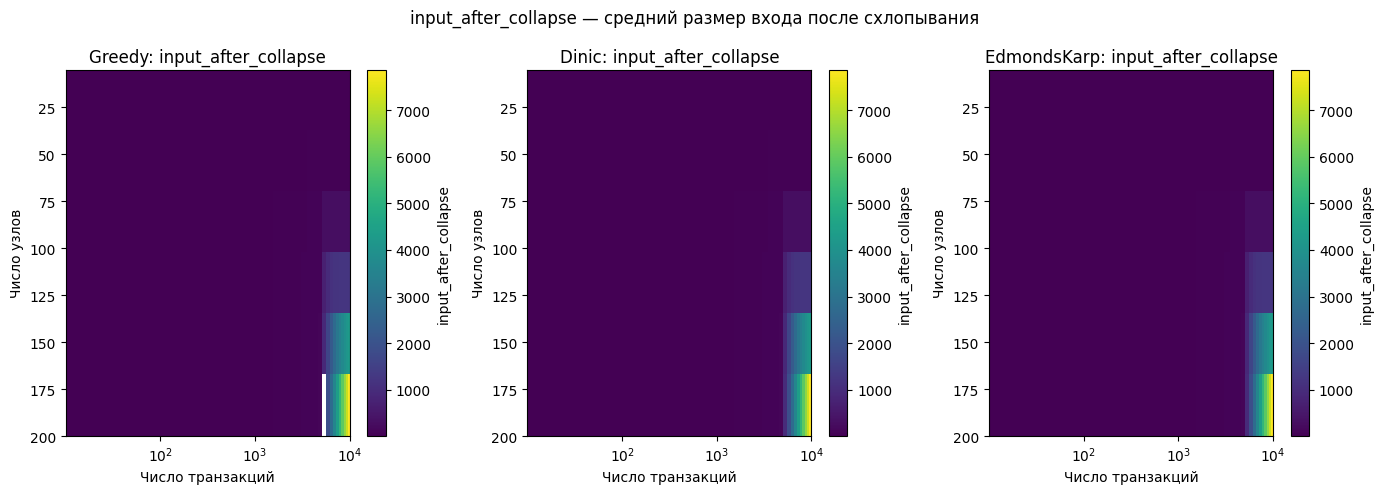

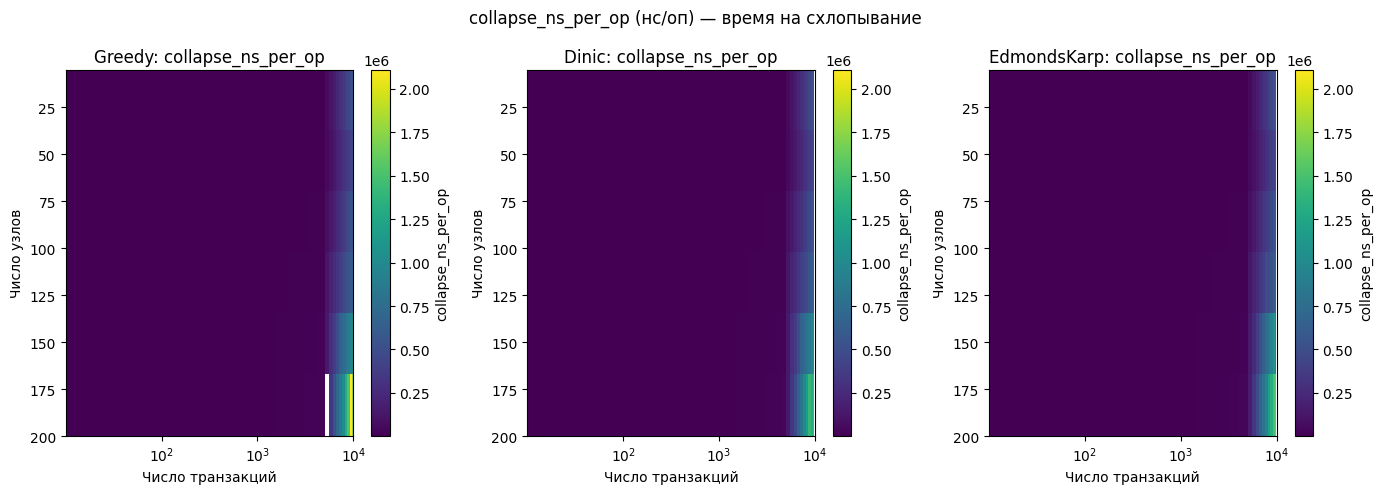

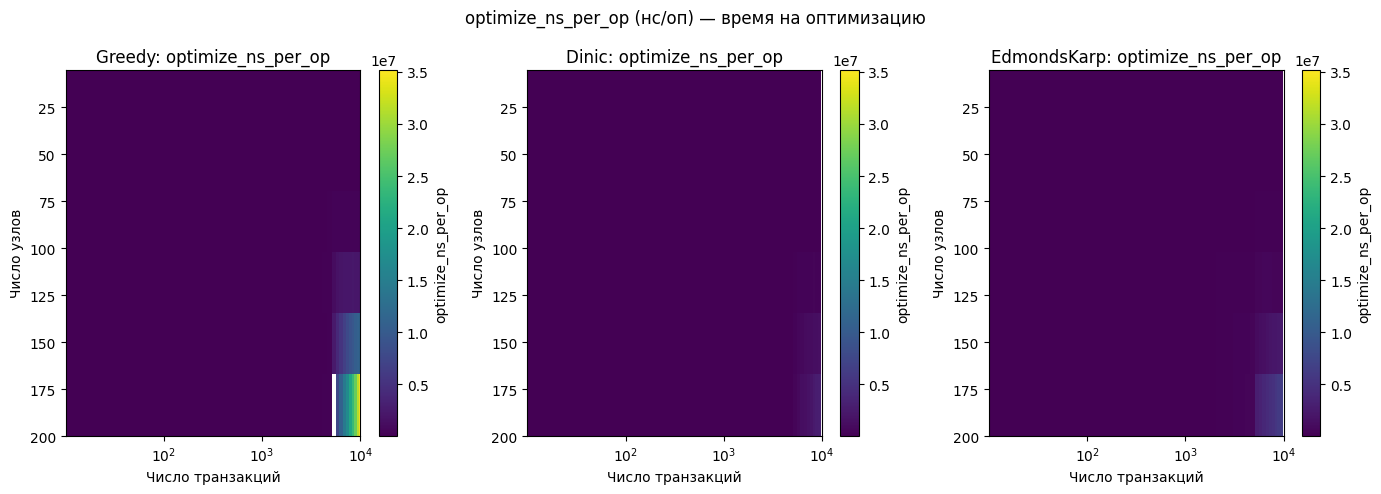

In [133]:
# Блок 4: тепловые карты по дополнительным метрикам (общая шкала по каждому метрике)
for metric, title in [
    ("collapse_pct", "collapse_pct (%) — доля схлопнутых транзакций"),
    ("input_after_collapse", "input_after_collapse — средний размер входа после схлопывания"),
    ("collapse_ns_per_op", "collapse_ns_per_op (нс/оп) — время на схлопывание"),
    ("optimize_ns_per_op", "optimize_ns_per_op (нс/оп) — время на оптимизацию"),
]:
    all_vals = []
    for algo in ["Greedy", "Dinic", "EdmondsKarp"]:
        sub = df_all[df_all["algorithm"] == algo]
        mat = pivot_metric(sub, metric=metric).sort_index(axis=0).sort_index(axis=1)
        if not mat.empty:
            all_vals.append(mat.values)
    vmin = np.nanmin(np.concatenate(all_vals)) if all_vals else 0
    vmax = np.nanmax(np.concatenate(all_vals)) if all_vals else 1
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    for idx, algo in enumerate(["Greedy", "Dinic", "EdmondsKarp"]):
        sub = df_all[df_all["algorithm"] == algo]
        mat = pivot_metric(sub, metric=metric).sort_index(axis=0).sort_index(axis=1)
        if mat.empty:
            continue
        nodes, trans = mat.index.values, mat.columns.values
        im = axes[idx].imshow(mat.values, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax,
                              extent=[trans.min(), trans.max(), nodes.max(), nodes.min()])
        axes[idx].set_xscale("symlog", linthresh=100)
        axes[idx].set_xlabel("Число транзакций")
        axes[idx].set_ylabel("Число узлов")
        axes[idx].set_title(f"{algo}: {metric}")
        plt.colorbar(im, ax=axes[idx], label=metric)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

## Итог для диплома

По графикам выше: по данным бенчмарка **Dinic** оказывается самым быстрым в большинстве конфигураций (наименьшее среднее время, чаще всего выигрывает по времени). **Greedy** — не самый быстрый и не гарантирует минимальное число транзакций (reduction_len_pct может быть отрицательным). **Edmonds–Karp** даёт оптимальный поток, но медленнее Dinic. Для сервиса оптимизации транзакций разумно выбрать **алгоритм Диница**: оптимальный результат и лучшее время среди трёх.

In [126]:
# Краткая сводка по данным (опционально)
mean_time = df_all.groupby("algorithm")["ns_per_op"].mean()
pivot_time = df_all.pivot_table(index=["nodes", "transactions"], columns="algorithm", values="ns_per_op", aggfunc="mean")
wins = pivot_time.idxmin(axis=1).value_counts()
print("Среднее время (мкс/оп):", (mean_time / 1000).round(1).to_dict())
print("Чаще всего самый быстрый (число конфигураций):", wins.to_dict())

Среднее время (мкс/оп): {'Dinic': 737.6, 'EdmondsKarp': 1108.1, 'Greedy': 2852.5}
Чаще всего самый быстрый (число конфигураций): {'Dinic': 92, 'Greedy': 27, 'EdmondsKarp': 1}


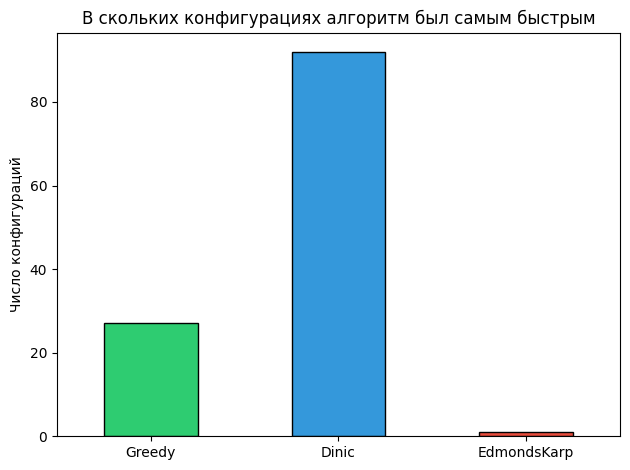

In [127]:
# Дополнительно: кто чаще был самым быстрым (из данных выше)
order = ["Greedy", "Dinic", "EdmondsKarp"]
wt = wins.reindex(order, fill_value=0)
wt.plot(kind="bar", color=["#2ecc71", "#3498db", "#e74c3c"], edgecolor="black")
plt.title("В скольких конфигурациях алгоритм был самым быстрым")
plt.ylabel("Число конфигураций")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Что можно вывести из цифр выше (для диплома):**

- **Greedy** — по данным бенчмарка в среднем самый медленный из трёх; **reduction_len_pct** и **reduce_success_pct** у него ниже (часто отрицательный reduction_len_pct). Не гарантирует минимальное число транзакций.
- **Dinic** и **EdmondsKarp** — дают оптимальный поток (минимальное число переводов), поэтому **reduction_len_pct** у них высокий. Dinic при этом быстрее Karp и чаще всего выигрывает по скорости (смотри столбик «кто быстрее» и среднее время).
- **Итог:** для сервиса оптимизации транзакций разумно выбрать **алгоритм Диница**: он даёт оптимальное сокращение транзакций при приемлемой скорости и быстрее Edmonds–Karp. Тепловые карты выше показывают, где именно (по узлам/транзакциям) разница во времени и качестве наиболее заметна.

## Качество оптимизации и валидность

- **reduce_success_pct** — среди валидных запусков доля тех, где число переводов сократилось хотя бы на 1.
- **reduction_len_pct** — средний процент сокращения числа переводов (качество); может быть отрицательным при ухудшении.
- **valid_pct** — среди успешных вызовов оптимизатора доля с валидным результатом (балансы сохранены).

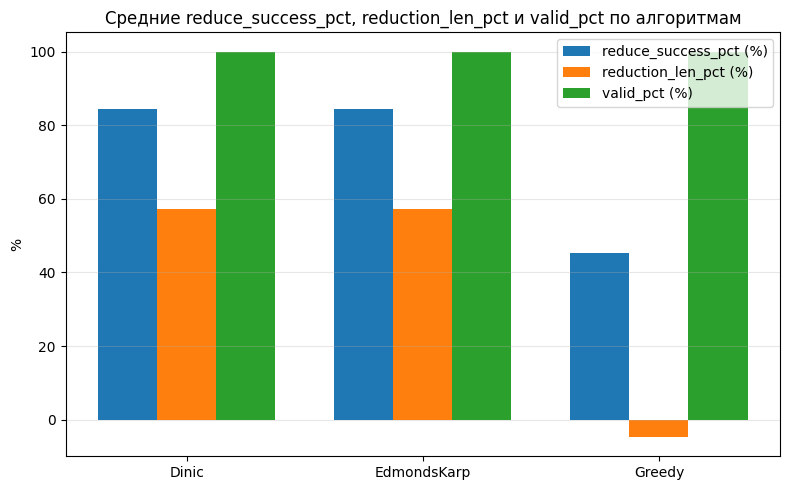

In [130]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# reduce_success_pct, reduction_len_pct и valid_pct по алгоритмам (усреднение по конфигурациям)
agg = df_all.groupby("algorithm").agg({"reduce_success_pct": "mean", "reduction_len_pct": "mean", "valid_pct": "mean"}).reset_index()
x = np.arange(len(agg))
w = 0.25
ax.bar(x - w, agg["reduce_success_pct"], w, label="reduce_success_pct (%)")
ax.bar(x, agg["reduction_len_pct"], w, label="reduction_len_pct (%)")
ax.bar(x + w, agg["valid_pct"], w, label="valid_pct (%)")
ax.set_xticks(x)
ax.set_xticklabels(agg["algorithm"])
ax.set_ylabel("%")
ax.set_title("Средние reduce_success_pct, reduction_len_pct и valid_pct по алгоритмам")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Сводная таблица для диплома

Средние метрики по всем конфигурациям бенчмарка — для краткого сравнения алгоритмов.

In [132]:
summary = df_all.groupby("algorithm").agg({
    "ns_per_op": "mean",
    "collapse_ns_per_op": "mean",
    "optimize_ns_per_op": "mean",
    "reduce_success_pct": "mean",
    "reduction_len_pct": "mean",
    "valid_pct": "mean",
    "bytes_per_op": "mean",
    "allocs_per_op": "mean",
}).round(2)
summary.columns = ["Время (нс/оп)", "collapse (нс/оп)", "optimize (нс/оп)", "reduce_success_pct (%)", "reduction_len_pct (%)", "valid_pct (%)", "Байт/оп", "Аллокаций/оп"]
summary

,Время (нс/оп),collapse (нс/оп),optimize (нс/оп),reduce_success_pct (%),reduction_len_pct (%),valid_pct (%),Байт/оп,Аллокаций/оп
algorithm,,,,,,,,
Dinic,737619.78,242316.42,316995.55,84.31,57.22,100.0,940546.38,3636.91
EdmondsKarp,1108058.89,245534.38,682799.11,84.34,57.22,100.0,1558138.92,4539.50
Greedy,2852490.03,256368.80,2473734.03,45.26,-4.69,100.0,3414809.90,14468.82


## Выводы для обоснования выбора алгоритма (диплом)

На основе графиков и таблицы можно сформулировать аргументы:

1. **Greedy** — по данным бенчмарка в среднем самый медленный; reduction_len_pct и reduce_success_pct ниже, чем у Dinic/Karp (часто отрицательный reduction_len_pct). Не гарантирует минимальное число транзакций.

2. **Dinic** — оптимальный поток (минимальное число транзакций), по данным бенчмарка самый быстрый в большинстве конфигураций и быстрее Edmonds–Karp; **рекомендуемый выбор для сервиса** при необходимости и оптимальности, и производительности.

3. **Edmonds–Karp** — тоже даёт оптимальный результат, но с большим временем и аллокациями; оправдан, когда важна простота реализации или сравнение с эталоном.

Для сервиса оптимизации транзакций разумно выбрать **алгоритм Диница**: он обеспечивает минимальное количество переводов при сравнимой или лучшей скорости, чем Edmonds–Karp, и умеренном потреблении памяти.